In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import torch
import urllib.request
import time
from tqdm import tqdm
from collections import Counter
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('dataset/IMDB Dataset.csv')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [4]:
df['sentiment'] = df['sentiment'].replace(["positive", "negative"], [1,0]).astype("int64")
df['sentiment']

/tmp/ipykernel_97333/4149482151.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace(["positive", "negative"], [1,0]).astype("int64")


0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [5]:
x_data = df['review']
y_data = df['sentiment']
print(f'영화 리뷰의 개수: {len(x_data)}')
print(f'레이블의 개수: {len(y_data)}')

영화 리뷰의 개수: 50000
레이블의 개수: 50000


In [6]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, stratify=y_data)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, stratify=y_train)

print(f'훈련용 리뷰의 개수: {len(x_train)}')
print(f'검증용 리뷰의 개수: {len(x_val)}')
print(f'테스트용 리뷰의 개수: {len(x_test)}')
print('----------------------------------')
print(f'훈련용 레이블의 긍정 비율: {y_train.sum()/len(y_train):.2f}')
print(f'검증용 레이블의 긍정 비율: {y_val.sum()/len(y_val):.2f}')
print(f'테스트용 레이블의 긍정 비율: {y_test.sum()/len(y_test):.2f}')

훈련용 리뷰의 개수: 32000
검증용 리뷰의 개수: 8000
테스트용 리뷰의 개수: 10000
----------------------------------
훈련용 레이블의 긍정 비율: 0.50
검증용 레이블의 긍정 비율: 0.50
테스트용 레이블의 긍정 비율: 0.50


In [7]:
def tokenize(sentences):
    tokenized_sentences = []
    for sentence in tqdm(sentences):
        tokenized_sentence = word_tokenize(sentence)
        tokenized_sentence = [word.lower() for word in tokenized_sentence]
        tokenized_sentences.append(tokenized_sentence)
    return tokenized_sentences

In [8]:
tokenized_x_train = tokenize(x_train)
tokenized_x_val = tokenize(x_val)
tokenized_x_test = tokenize(x_test)

100%|██████████| 10000/10000 [00:04<00:00, 2291.04it/s]


In [9]:
[print(sent) for sent in tokenized_x_train[:3]]

['a', 'cheesy', '``', 'b', "''", 'crime', 'thriller', 'of', 'the', 'early', "'50", ',', 'the', 'story', 'is', 'droll', ',', 'the', 'characters', 'wooden', ',', 'allison', 'hayes', 'and', 'abbe', 'lane', 'are', 'the', 'only', 'two', 'sexpots', 'that', 'make', 'it', 'an', 'eye-catcher', ',', 'but', 'one', 'short', 'shot', ',', 'only', 'a', 'few', 'frames', 'long', ',', 'shows', 'an', '``', 'el', "''", 'train', 'crossing', 'the', 'river', 'on', 'the', 'state', 'street', 'bridge', ',', 'of', 'the', '6000', 'series', 'pullman-built', 'cars', 'painted', 'in', 'their', 'original', '1950', 'paint', 'scheme', ',', 'as', 'they', 'were', 'delivered', 'when', 'new', 'in', '1950', '.', 'for', 'traction', 'fans', 'like', 'me', ',', 'that', 'one', 'short', 'take', 'makes', 'the', 'picture', 'worthwhile', '.', 'i', 'think', 'films', 'like', 'this', 'one', ',', 'ulmer', "'s", 'detour', ',', 'd.o.a', '.', 'with', 'edmund', "o'brien", ',', 'the', 'fugitive', 'with', 'harrison', 'ford', ',', 'and', 'other

[None, None, None]

In [10]:
word_list = [word for sentecne in tokenized_x_train for word in sentecne]
word_counts = Counter(word_list)
print(f'단어 집합의 크기: {len(word_counts)}')
print(f"자주 등장하는 단어의 등장 횟수: {word_counts.most_common()[:10]}")

단어 집합의 크기: 128993
자주 등장하는 단어의 등장 횟수: [('the', 424855), (',', 346146), ('.', 298532), ('and', 206492), ('a', 205218), ('of', 184339), ('to', 170534), ('is', 138569), ('/', 129205), ('>', 129154)]


In [11]:
vocabs = sorted(word_counts, key=word_counts.get, reverse=True)
print(f'단어 집합의 크기: {len(vocabs)}')
print(f'자주 등장하는 단어 10개: {vocabs[:10]}')

단어 집합의 크기: 128993
자주 등장하는 단어 10개: ['the', ',', '.', 'and', 'a', 'of', 'to', 'is', '/', '>']


In [12]:
# 등장 횟수가 작은 단어들을 제거
threshold = 3
total_words, total_freq = len(vocabs), 0
rare_words, rare_freq = 0, 0

for word, count in word_counts.items():
    total_freq += count
    if count < threshold:
        rare_words += 1
        rare_freq += count

print(f'단어 집합의 크기: {total_words}')
print(f'등장 빈도가 {threshold}번 이하인 희귀 단어의 개수: {rare_words}')
print(f'희귀 단어 비율: {rare_words/total_words*100:.2f}%')
print(f'전체 등장 빈도에서 희귀 단어가 차지하는 비율: {rare_freq/total_freq*100:.2f}%')

단어 집합의 크기: 128993
등장 빈도가 3번 이하인 희귀 단어의 개수: 80529
희귀 단어 비율: 62.43%
전체 등장 빈도에서 희귀 단어가 차지하는 비율: 1.08%


In [13]:
vocabs = vocabs[:total_words - rare_words]
word_to_index = {"<PAD>": 0, "<OOV>": 1} | {word: index + 2 for index, word in enumerate(vocabs)}
vocal_size = len(word_to_index)
print(f'단어 집합의 크기: {vocal_size}')

단어 집합의 크기: 48466


In [25]:
# 텍스트 시퀀스를 정수 시퀀스로 변환
def encode_sequences(tokenized_sentences, word_to_index):
    encoded_sentences = []
    for sentences in tokenized_sentences:
        index_sequence = []
        for word in sentences:
            index_sequence.append(word_to_index.get(word, 1))
        encoded_sentences.append(index_sequence)
        
    return encoded_sentences

def decode_sequences(encoded_sentences, index_to_word):
    decoded_sentences = []
    for sentence in encoded_sentences:
        word_sequence = []
        for code in sentence:
            word_sequence.append(index_to_word.get(code))
        decoded_sentences.append(word_sequence)
    
    return decoded_sentences

index_to_word = {value: key for key, value in word_to_index.items()}

In [26]:
encoded_x_train = encode_sequences(tokenized_x_train, word_to_index)
encoded_x_val = encode_sequences(tokenized_x_val, word_to_index)
encoded_x_test = encode_sequences(tokenized_x_test, word_to_index)

In [27]:
[print(sent) for sent in encoded_x_train[:3]]

[6, 911, 33, 990, 30, 819, 778, 7, 2, 415, 17982, 3, 2, 81, 9, 10336, 3, 2, 120, 1667, 3, 11961, 5569, 5, 1, 2274, 35, 2, 77, 129, 1, 18, 112, 14, 46, 1, 3, 25, 40, 351, 331, 3, 77, 6, 185, 6137, 219, 3, 289, 46, 33, 5116, 30, 1066, 4460, 2, 1918, 31, 2, 1108, 905, 3024, 3, 7, 2, 35767, 231, 1, 1824, 4135, 15, 78, 220, 2725, 2937, 4229, 3, 21, 44, 82, 2037, 64, 181, 15, 2725, 4, 22, 35768, 482, 50, 84, 3, 18, 40, 351, 209, 177, 2, 453, 2452, 4, 16, 119, 124, 50, 17, 40, 3, 29403, 19, 18763, 3, 29404, 4, 23, 8513, 7068, 3, 2, 8159, 23, 4733, 1509, 3, 5, 409, 7, 2, 26, 1684, 536, 3, 28, 213, 531, 819, 3336, 27, 112, 14, 235, 58, 22, 174, 99, 90, 2, 208, 18, 16, 138, 3337, 5, 2871, 4402, 19500, 5, 2461, 106, 7, 2, 905, 1815, 4, 99, 2233, 14, 19, 6, 76, 10336, 356, 26, 41]
[14, 2601, 17, 9, 6, 716, 26, 3, 3966, 3, 23, 2, 4104, 31, 203, 526, 23, 92, 923, 350, 88, 153, 9, 14, 2, 716, 35, 49, 22639, 31, 17, 256, 7, 166, 60, 64, 2, 632, 1473, 9, 17, 98, 3, 14, 76, 277, 143, 21, 29405, 41, 2724

[None, None, None]

In [17]:
decoding_test = decode_sequences(encoded_x_train[:3], index_to_word)
[print(decode) for decode in decoding_test]

['a', 'cheesy', '``', 'b', "''", 'crime', 'thriller', 'of', 'the', 'early', "'50", ',', 'the', 'story', 'is', 'droll', ',', 'the', 'characters', 'wooden', ',', 'allison', 'hayes', 'and', None, 'lane', 'are', 'the', 'only', 'two', None, 'that', 'make', 'it', 'an', None, ',', 'but', 'one', 'short', 'shot', ',', 'only', 'a', 'few', 'frames', 'long', ',', 'shows', 'an', '``', 'el', "''", 'train', 'crossing', 'the', 'river', 'on', 'the', 'state', 'street', 'bridge', ',', 'of', 'the', '6000', 'series', None, 'cars', 'painted', 'in', 'their', 'original', '1950', 'paint', 'scheme', ',', 'as', 'they', 'were', 'delivered', 'when', 'new', 'in', '1950', '.', 'for', 'traction', 'fans', 'like', 'me', ',', 'that', 'one', 'short', 'take', 'makes', 'the', 'picture', 'worthwhile', '.', 'i', 'think', 'films', 'like', 'this', 'one', ',', 'ulmer', "'s", 'detour', ',', 'd.o.a', '.', 'with', 'edmund', "o'brien", ',', 'the', 'fugitive', 'with', 'harrison', 'ford', ',', 'and', 'others', 'of', 'the', 'film', 'n

[None, None, None]

리뷰의 최대 길이: 2651
리뷰의 평균 길이:  278.665375


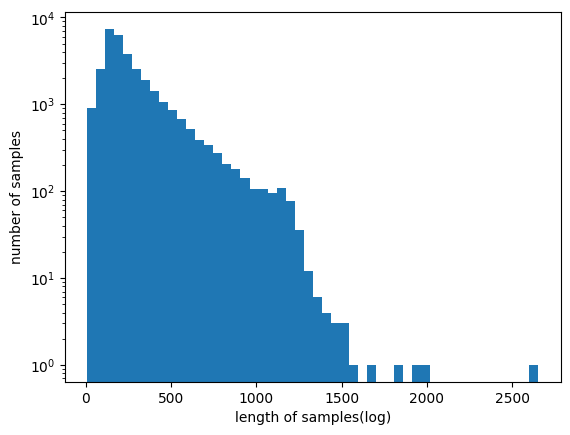

In [18]:
# 인코딩된 시퀀스를 적절한 길이로 패딩
print(f'리뷰의 최대 길이: {max(len(review) for review in encoded_x_train)}')
print(f'리뷰의 평균 길이: {np.mean([len(review) for review in encoded_x_train]): 2f}')
plt.hist([len(review) for review in encoded_x_train], bins=50, log=True)
plt.xlabel('length of samples(log)')
plt.ylabel('number of samples')
plt.show()



In [19]:
def ratio_below_threshold_len(threshold, data):
    count = sum([1 for entry in data if len(entry) < threshold])
    return f'{count/len(data)*100:0.2f}%'

In [92]:
max_len = 1000
print(f'문장 길이가 {max_len} 이하인 샘플의 비율: {ratio_below_threshold_len(max_len, encoded_x_train)}')

문장 길이가 1000 이하인 샘플의 비율: 98.51%


In [93]:
def pad_sequences(encoded_sentences, threshold):
    padded_sequences = np.zeros((len(encoded_sentences), threshold), dtype=int)
    for index, sentence in enumerate(encoded_sentences):
        if sentence:
            length = len(sentence)
            padded_sequences[index, :length] = np.array(sentence)[:threshold]
    return padded_sequences

In [94]:
padded_x_train = pad_sequences(encoded_x_train, max_len)
padded_x_val = pad_sequences(encoded_x_val, max_len)
padded_x_test = pad_sequences(encoded_x_test, max_len)

print(f'훈련 데이터의 크기: {padded_x_train.shape}')
print(f'검증 데이터의 크기: {padded_x_val.shape}')
print(f'테스트 데이터의 크기: {padded_x_test.shape}')

훈련 데이터의 크기: (32000, 1000)
검증 데이터의 크기: (8000, 1000)
테스트 데이터의 크기: (10000, 1000)


In [30]:
# 모델 작성
import torch
import torch.nn as nn
import torch.nn.functional as F

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif torch.xpu.is_available():
    device = "xpu"
    
print(f'사용 기기: {device}')

사용 기기: xpu


In [95]:
train_data_tensor = torch.tensor(padded_x_train).to(torch.int64)
val_data_tensor = torch.tensor(padded_x_val).to(torch.int64)
test_data_tensor = torch.tensor(padded_x_test).to(torch.int64)
train_label_tensor = torch.tensor(np.array(y_train))
val_label_tensor = torch.tensor(np.array(y_val))
test_label_tensor = torch.tensor(np.array(y_test))

print(f'학습 데이터: {train_data_tensor.shape}')
print(f"학습 레이블: {train_label_tensor.shape}")

학습 데이터: torch.Size([32000, 1000])
학습 레이블: torch.Size([32000])


In [88]:
class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, output_dim):
        super(SentimentClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, batch):
        embedded = self.embedding(batch)
        gru_out, hidden = self.gru(embedded)
        last_hidden = hidden[-1]
        logits = self.fc(last_hidden)
        return logits

In [39]:
def load_data(data, label, batch_size=512):
    dataset = torch.utils.data.TensorDataset(data, label)
    dataloader = torch.utils.data.DataLoader(dataset, shuffle=True, batch_size=batch_size)
    return dataloader

In [96]:
train_dataloader = load_data(train_data_tensor, train_label_tensor, batch_size = 64)
val_dataloader = load_data(val_data_tensor, val_label_tensor)
test_dataloader = load_data(test_data_tensor, test_label_tensor)

print(f'총 훈련 배치의 수: {len(train_dataloader)}')

총 훈련 배치의 수: 500


In [ ]:
embedding_dim = 300
hidden_dim = 256
num_layers = 2
output_dim = 2
learning_rate = 0.001
num_epochs = 15

model = SentimentClassifier(vocal_size, embedding_dim, hidden_dim, num_layers, output_dim)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [72]:
def calculate_accuracy(logits, labels):
    predicted = torch.argmax(logits, dim=1)
    correct = (predicted == labels).sum().item()
    return correct/labels.size(0)

def evaluate(model, valid_dataloader, criterion, device):
    val_loss = 0
    val_correct = 0
    val_size = 0
    
    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in valid_dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            batch_size = batch_y.size(0)
            
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            
            val_loss += loss.item()
            val_correct += calculate_accuracy(logits, batch_y) * batch_size
            val_size += batch_size
    
    val_accuracy = val_correct / val_size
    val_loss /= len(valid_dataloader)
    
    return val_loss, val_accuracy

In [ ]:
# 학습
best_val_loss = float("inf")

for epoch in range(num_epochs):
    time_start = time.time()
    train_loss = 0
    train_correct = 0
    train_size = 0
    model.train()
    
    for batch_x, batch_y in tqdm(train_dataloader):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        batch_size = batch_y.size(0)

        #forward pass
        logits = model(batch_x)
        
        #compute loss
        loss = criterion(logits, batch_y)
        
        #backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # calculateing training metrics
        train_loss += loss.item()
        train_correct += calculate_accuracy(logits, batch_y) * batch_size
        train_size += batch_size
    
    train_accuracy = train_correct / train_size
    train_loss /= len(train_dataloader)
    
    val_loss, val_accuracy = evaluate(model, val_dataloader, criterion, device)
    
    print(f'Epoch {epoch+1}/{num_epochs}: ({(time.time() - time_start):0.2f}s)')
    print(f'train loss: {train_loss:0.4f}, train+accuracy: {train_accuracy:0.4f}')
    print(f'validation loss: {val_loss:0.4f}, validation_accuracy: {val_accuracy:0.4f}')
    
    if val_loss < best_val_loss:
        print(f'Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}. 체크포인트를 저장합니다.')
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'models/best_model_checkpoint_diy.pth')

 78%|███████▊  | 391/500 [08:02<02:14,  1.23s/it]


KeyboardInterrupt: 

In [98]:
model.load_state_dict(torch.load('models/best_model_checkpoint_diy.pth'))
model.to(device)

FileNotFoundError: [Errno 2] No such file or directory: 'models/best_model_checkpoint_diy.pth'

In [ ]:
# 검증 데이터에 대한 정확도와 손실 계산
val_loss, val_accuracy = evaluate(model, val_dataloader, criterion, device)

print(f'Best model validation loss: {val_loss:.4f}')
print(f'Best model validation accuracy: {val_accuracy:.4f}')

In [104]:
lable_parse = {0: "부정", 1: "긍정"}

def predict(text, model, word_to_index, lable_parse):
    model.eval()
    tokens = word_tokenize(text)
    token_indices = [word_to_index.get(token.lower(), 1) for token in tokens]
    
    input_tensor = torch.tensor([token_indices], dtype=torch.long).to(device)
    
    with torch.no_grad():
        logits = model(input_tensor)
    
    predicted = torch.argmax(logits, dim=1)
    return lable_parse[predicted.item()]

In [105]:
test_input = "This movie was just way too overrated. The fighting was not professional and in slow motion. I was expecting more from a 200 million budget movie. The little sister of T.Challa was just trying too hard to be funny. The story was really dumb as well. Don't watch this movie if you are going because others say its great unless you are a Black Panther fan or Marvels fan."

predict(test_input, model, word_to_index, lable_parse)

'부정'